### PCA analysis

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/drug_discovery_virtual_screening_cleaned.csv")
df = df.drop(columns=["Unnamed: 0"])

features = df.drop(columns=["active"])
target = df["active"]

stnd = StandardScaler().set_output(transform='pandas')
features = stnd.fit_transform(features)

In [20]:
#First I'll run a PCA with as many components as we have features. As I observe the explained variance, I'll see which features matter
#I'll lower the number of components to see which features 
#Think I got this with 3 features
pca = PCA(n_components=13)
pca.fit(features)
index = ['PC-'+str(i+1) for i in range(13)]
PVE = pca.explained_variance_ratio_
PVE = pd.DataFrame(PVE, index=index)
PVE.head(10)

,0
PC-1,0.147350
PC-2,0.142815
PC-3,0.083791
PC-4,0.081222
PC-5,0.079249
PC-6,0.078309
PC-7,0.077503
PC-8,0.074579
PC-9,0.073761
PC-10,0.072298


In [21]:
loadings = pca.components_
loadingsDF = pd.DataFrame(loadings, index=index, columns=features.columns)
loadingsDF.round(4)

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
PC-1,0.0552,0.5862,-0.0426,-0.0027,0.0092,0.0268,0.0120,-0.2585,0.3042,-0.0240,-0.0033,0.2535,0.6530
PC-2,0.2134,-0.2212,-0.0382,0.0656,0.0115,0.0175,0.0211,-0.6142,-0.1322,-0.0265,0.0466,0.6582,-0.2607
PC-3,-0.1380,0.2124,-0.4639,0.2419,0.1033,-0.1142,0.5175,-0.0294,-0.4341,-0.0268,-0.4229,-0.0405,-0.0114
PC-4,-0.2529,0.0420,0.3736,-0.3417,0.3496,0.1761,0.3326,-0.1180,-0.0897,0.6256,0.0013,0.0259,-0.0036
PC-5,0.5862,-0.0332,-0.1595,0.0136,0.4709,0.5854,0.0633,0.2287,0.0423,-0.0699,-0.0449,-0.0112,0.0104
PC-6,0.5268,-0.0092,-0.1812,-0.4553,-0.3806,-0.3319,0.3653,0.1623,0.0611,0.2230,0.1147,0.0278,-0.0039
PC-7,-0.0498,0.2025,-0.0969,0.2428,-0.3588,0.3954,0.0754,0.0240,-0.3863,0.1553,0.6492,-0.0399,0.0185
PC-8,0.1150,-0.1713,0.0332,0.5781,-0.3079,0.1137,0.0412,0.0355,0.3702,0.5324,-0.3015,0.0032,0.0059
PC-9,0.2654,0.0601,0.4945,0.4559,0.2880,-0.4305,0.3050,0.0932,-0.0570,-0.1351,0.2835,-0.0223,0.0344
PC-10,0.0194,0.0209,0.5135,-0.1071,-0.4325,0.3696,0.3481,-0.0145,-0.0499,-0.4157,-0.3219,0.0081,-0.0054


0    0.981406
dtype: float64


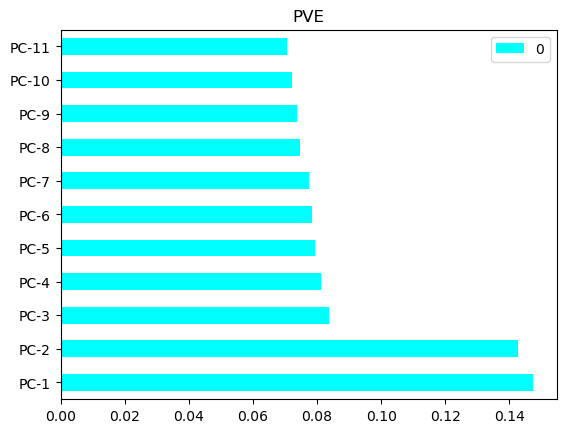

In [22]:
import matplotlib.pyplot as plt
pca = PCA(n_components=11)
pca.fit(features)
index = ['PC-'+str(i+1) for i in range(11)]
PVE = pca.explained_variance_ratio_
PVE = pd.DataFrame(PVE, index=index)
PVE.plot.barh(color='cyan',title='PVE')
print(PVE.sum())

In [23]:
loadings = pca.components_
loadingsDF = pd.DataFrame(loadings, index=index, columns=features.columns)
loadingsDF.round(4)

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
PC-1,0.0552,0.5862,-0.0426,-0.0027,0.0092,0.0268,0.0120,-0.2585,0.3042,-0.0240,-0.0033,0.2535,0.6530
PC-2,0.2134,-0.2212,-0.0382,0.0656,0.0115,0.0175,0.0211,-0.6142,-0.1322,-0.0265,0.0466,0.6582,-0.2607
PC-3,-0.1380,0.2124,-0.4639,0.2419,0.1033,-0.1142,0.5175,-0.0294,-0.4341,-0.0268,-0.4229,-0.0405,-0.0114
PC-4,-0.2529,0.0420,0.3736,-0.3417,0.3496,0.1761,0.3326,-0.1180,-0.0897,0.6256,0.0013,0.0259,-0.0036
PC-5,0.5862,-0.0332,-0.1595,0.0136,0.4709,0.5854,0.0633,0.2287,0.0423,-0.0699,-0.0449,-0.0112,0.0104
PC-6,0.5268,-0.0092,-0.1812,-0.4553,-0.3806,-0.3319,0.3653,0.1623,0.0611,0.2230,0.1147,0.0278,-0.0039
PC-7,-0.0498,0.2025,-0.0969,0.2428,-0.3588,0.3954,0.0754,0.0240,-0.3863,0.1553,0.6492,-0.0399,0.0185
PC-8,0.1150,-0.1713,0.0332,0.5781,-0.3079,0.1137,0.0412,0.0355,0.3702,0.5324,-0.3015,0.0032,0.0059
PC-9,0.2654,0.0601,0.4945,0.4559,0.2880,-0.4305,0.3050,0.0932,-0.0570,-0.1351,0.2835,-0.0223,0.0344
PC-10,0.0194,0.0209,0.5135,-0.1071,-0.4325,0.3696,0.3481,-0.0145,-0.0499,-0.4157,-0.3219,0.0081,-0.0054


### SVM

In [ ]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

features_train, features_test, target_train, target_test = train_test_split(
  features, target, test_size=0.2, stratify=target, random_state=42
)

svm = svm.SVC()
grid = {"kernel": ['linear', 'poly', 'rbf'], "gamma": np.logspace(2, 100, 10), "C": [0.01, 1, 100, 1000]}
gridSVM = GridSearchCV(
    svm,
    param_grid=grid,
    n_jobs=-1,
    scoring="roc_auc",
    cv=5,
    error_score='raise'
)

gridSVM.fit(features_train, target_train)


ValueError: The dual coefficients or intercepts are not finite. The input data may contain large values and need to be preprocessed.

In [ ]:
svm_best = gridSVM.best_estimator_
target_test_predict = svm_best.predict(features_test, error_score='raise')
test_prob = svm_best.predict_proba(features_test)[:, 1]

accuracy = accuracy_score(target_test, target_test_predict)
roc_auc = roc_auc_score(target_test, test_prob)

print("=== SVM ===")
print("Best Params:", gridSVM.best_params_)
print(classification_report(target_test, target_test_predict))
print("ROC-AUC:", roc_auc_score(target_test, test_prob))

### Logistic Regression - Ridge Regularization